In [2]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [3]:
def prepare_transition_set_ofret(number_fluorophores, distance):
    fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=distance, count=number_fluorophores, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

    transitions = fluorophore_system.load_transitions(
    summarize=True,
    irradiance=5,
    wavelength=640,
    bleaching=True,
    energy_transfer=True,
    dstorm=True,
    dstorm_parameters={'reducing_agent':'mea',
    'concentration':100,
    'ph':7.5},
    energy_transfer_parameters={'overwrite': {'off': [1, 0.0001]}, 
                                'exclude': ['s0']}
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()

    return transition_set


In [90]:
transition_set = prepare_transition_set_ofret(2, 3)
rng = np.random.default_rng(42)
emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
Da, D, lifetimes_all, time_series, transition_series, excitation_series = \
    emis.tcspc(transition_set, number_pulses=5e1, excitation_rates={'cy5_dna': 1.5e11}, return_details=True)

WARNING for line:         warnings.warn(
 Not enough laser pulses to completely simulate a single frame (requires at least 1.0e+04 pulses). 
WARNING for line:     warnings.warn(
 the last frame (of index 0.001) has 5.00e-03 times the pulses of other frames. 


In [54]:
sim = si.Simulation(transition_set)
sim.transition_series = transition_series
sim.state_series = get_state_series(transition_set, transition_series)
sim.time_series = time_series
#
analyis = an.Analysis(sim)

array([[<Axes: ylabel='Prob. occurrence'>]], dtype=object)

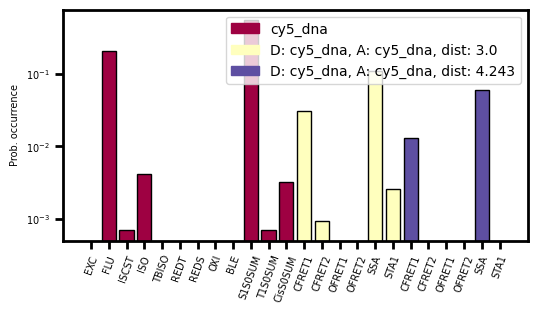

In [58]:
analyis.plot_frequency_transitions(fontsize=7)

In [ ]:
state_series = get_state_series(transition_set, transition_series)

In [48]:
time_series.size

4330

In [12]:
transition_set.combined_state_transitions_df

,initial_state,final_state,fluorophore_ids,abbreviation,transition_id,rate,photon
id,,,,,,,
0,"(0, 0, 0, 0)","(0, 0, 0, 1)",[3],EXC,0,1.453925e+07,False
1,"(0, 0, 0, 0)","(0, 0, 1, 0)",[2],EXC,0,1.453925e+07,False
2,"(0, 0, 0, 0)","(0, 1, 0, 0)",[1],EXC,0,1.453925e+07,False
3,"(0, 0, 0, 0)","(1, 0, 0, 0)",[0],EXC,0,1.453925e+07,False
4,"(0, 0, 0, 1)","(0, 0, 1, 1)",[2],EXC,0,1.453925e+07,False
...,...,...,...,...,...,...,...
7295,"(7, 3, 1, 0)","(7, 3, 0, 0)","[2, 1]",STA1,22,4.515524e+09,False
7296,"(7, 3, 1, 1)","(7, 3, 0, 1)","[2, 1]",STA1,22,4.515524e+09,False
7297,"(7, 3, 1, 3)","(7, 3, 0, 3)","[2, 1]",STA1,22,4.515524e+09,False


In [11]:
transition_set.combined_state_transitions_df.iloc[4075]

initial_state          (1, 0, 0, 0)
final_state            (0, 0, 0, 0)
fluorophore_ids                 [0]
abbreviation                S1S0SUM
transition_id                     8
rate               427647107.709054
photon                        False
Name: 4075, dtype: object

In [9]:
transition_series

array([4075, 4075, 4000, ..., 6303,  510, 4000])

In [4]:
transition_set = prepare_transition_set_ofret(4, 3)
rng = np.random.default_rng(42)
emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
DA, D, lifetimes_all = emis.tcspc(transition_set, number_pulses=3e7, excitation_rates={'cy5_dna': 1.5e10})

WARNING for line:     warnings.warn(
 the last frame (of index 3.0) has 0.00e+00 times the pulses of other frames. 


array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

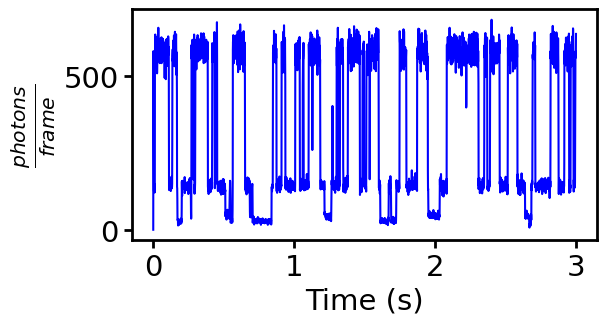

In [13]:
emis.plot_time_series()

In [20]:
transition_set = prepare_transition_set_ofret(4, 9)
rng = np.random.default_rng(42)
emis_9 = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
DA_9, D_9, lifetimes_all_9 = emis_9.tcspc(transition_set, number_pulses=3e7, excitation_rates={'cy5_dna': 1.5e10})

WARNING for line:     warnings.warn(
 the last frame (of index 3.0) has 0.00e+00 times the pulses of other frames. 


array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

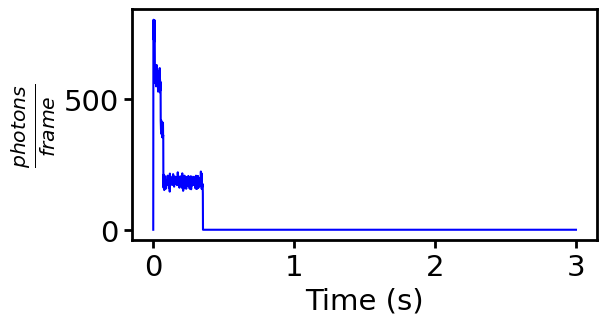

In [21]:
emis_9.plot_time_series()

In [24]:
blinks_9 = bl.Blinking(emis_9, threshold=20)

In [25]:
blinks_9.off_periods

array([], dtype=int64)

In [36]:
DA.mean()

6.72575006826046e-10

In [38]:
DA.size/D.size

0.23200900884861217

In [37]:
lifetimes_all.mean()

1.5036185411580305e-09

array([[<Axes: title={'center': 'lifetimes'}, xlabel='time (s)', ylabel='PD'>]],
      dtype=object)

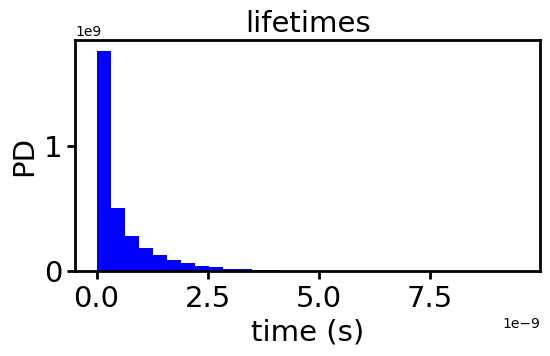

In [29]:
fi.universal_figure(data=DA, type_='hist', density=True, 
                    title='lifetimes', 
                    ylabel='PD', xlabel='time (s)', 
                     bins=30) 

In [18]:
transition_set.transition_df

transition_type  \
Fluorophore                         identity                                           
cy5_dna                             0                      TransitionType.EXCITATION   
                                    1            TransitionType.FLUORESCENT_EMISSION   
                                    2         TransitionType.INTERSYSTEM_CROSSING_ST   
                                    3                   TransitionType.ISOMERIZATION   
                                    4                      TransitionType.THERM_BISO   
                                    5                     TransitionType.REDUCTION_T   
                                    6                     TransitionType.REDUCTION_S   
                                    7                     TransitionType.OXIDATION_1   
                                    8               TransitionType.S1_S0_TRANSITIONS   
                                    9               TransitionType.T1_S0_TRANSITIONS   
                                    10             TransitionType.CIS_S0_TRANSITIONS   
D: cy5_dna, A: cy5_dna, dist: 3.0   11                     TransitionType.CIS_FRET_1   
                                    12                     TransitionType.CIS_FRET_2   
                                    13                     TransitionType.OFF_FRET_1   
                                    14                     TransitionType.OFF_FRET_2   
                                    15               TransitionType.S_S_ANNIHILATION   
                                    16             TransitionType.S_T_ANNIHILATION_1   
D: cy5_dna, A: cy5_dna, dist: 4.243 17                     TransitionType.CIS_FRET_1   
                                    18                     TransitionType.CIS_FRET_2   
                                    19                     TransitionType.OFF_FRET_1   
                                    20                     TransitionType.OFF_FRET_2   
                                    21               TransitionType.S_S_ANNIHILATION   
                                    22             TransitionType.S_T_ANNIHILATION_1   

                                             abbreviation  \
Fluorophore                         identity                
cy5_dna                             0                 EXC   
                                    1                 FLU   
                                    2               ISCST   
                                    3                 ISO   
                                    4               TBISO   
                                    5                REDT   
                                    6                REDS   
                                    7                OXI1   
                                    8             S1S0SUM   
                                    9             T1S0SUM   
                                    10           CisS0SUM   
D: cy5_dna, A: cy5_dna, dist: 3.0   11             CFRET1   
                                    12             CFRET2   
                                    13             OFRET1   
                                    14             OFRET2   
                                    15                SSA   
                                    16               STA1   
D: cy5_dna, A: cy5_dna, dist: 4.243 17             CFRET1   
                                    18             CFRET2   
                                    19             OFRET1   
                                    20             OFRET2   
                                    21                SSA   
                                    22               STA1   

                                                    initial_state  \
Fluorophore                         identity                        
cy5_dna                             0              SingleState.S0   
                                    1              SingleState.S1   
                                    2              SingleState.S1 

In [11]:
distances = [3, 6, 9, 18]
rng = np.random.default_rng(42)
lifetimes_all_distances = []
for distance in distances:
    transition_set = prepare_transition_set_ofret(4, distance)
    emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
    _, _, lifetimes_all = emis.tcspc(transition_set, number_pulses=2e6, excitation_rates={'cy5_dna': 1.5e10})
    lifetimes_all_distances.append(lifetimes_all)

WARNING for line:     warnings.warn(
 the last frame (of index 0.199) has 1.00e+00 times the pulses of other frames. 
WARNING for line:     warnings.warn(
 the last frame (of index 0.199) has 1.00e+00 times the pulses of other frames. 
WARNING for line:     warnings.warn(
 the last frame (of index 0.199) has 1.00e+00 times the pulses of other frames. 
WARNING for line:     warnings.warn(
 the last frame (of index 0.199) has 1.00e+00 times the pulses of other frames. 


1.6431152602667397e-09
1.5839440111851311e-09
1.635775190633464e-09
1.6711895573268461e-09


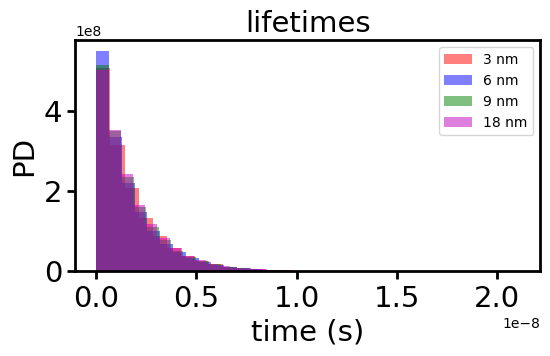

In [15]:
axes = fi.universal_figure()
colors = ['r', 'b', 'g', 'm']
for i, (lifetimes, distance) in enumerate(zip(lifetimes_all_distances, distances)):
    print(np.mean(lifetimes))
    fi.universal_figure(data=lifetimes, type_='hist', density=True, 
                        axes=axes[0, 0], title='lifetimes', 
                        ylabel='PD', xlabel='time (s)', label=f'{distance} nm',
                        legend=True, color=colors[i], bins=30, alpha=0.5)   